In [2]:
import scanpy as sc
import numpy as np
import h5py
import json
import matplotlib.pyplot as plt
import torch
import argparse
import json
import pickle
import pandas as pd

import sys
sys.path.insert(0, "/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC/")


from src.tf2rNet.models import MotifNet
from src.tf2rNet.utils import *

from src.deepSCENIC import deepSCENIC
import src.utils as utils

from captum.attr import DeepLiftShap, InputXGradient
from enformer_pytorch import Enformer

### Load tf2rNet model

In [5]:
RES_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/results/MM_lines_Enformer3/'

parser = argparse.ArgumentParser()
opt = parser.parse_args('')
with open(RES_PATH + "/hyperparma.txt", 'r') as f:
            opt.__dict__.update(json.load(f))

# Select device 'cpu' or 'cuda' (gpu)
opt.device = 'cuda'
if opt.device=='cuda':
    Tensor = torch.cuda.FloatTensor
elif opt.device=='cpu':
    Tensor = torch.FloatTensor

In [10]:
opt.train = False
opt.use_best = True
opt.data_rna_file_test = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/raw_exprMat_test.h5ad'

In [11]:
# Compile model
ds_model = deepSCENIC(opt)
dataloader, TFs_idx, r2g_dist_coo, seq_dataloader, _ = ds_model.init_data()

dir exist
reading data...
data read!
AnnData object with n_obs × n_vars = 936 × 12188
    var: 'n_cells'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 936 × 281820


In [12]:
# Read gene expression data and cell annotations
DATA_PATH = '/staging/leuven/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/'

ad = sc.read(opt.data_rna_file)
cells_metadata = pd.read_csv(DATA_PATH + '/cells_metadata.csv', index_col=0)
ad.obs[cells_metadata.columns] = cells_metadata.loc[ad.obs.index,:].values
# Load latent representations
ad.obsm['z_rna'] = np.load(opt.save_name + 'z_rna.npy', allow_pickle=True) # Latent target gene expression
ad.obsm['y_rna'] = np.load(opt.save_name + 'y_rna.npy', allow_pickle=True) # Predicted target gene expression
ad.obsm['y_atac'] = np.load(opt.save_name + 'y_atac.npy', allow_pickle=True) # Predicted chromatin accessibility
ad.obsm['enh_act'] = np.load(opt.save_name + 'z_rna_atac.npy', allow_pickle=True) # Predicted enhancer activity
ad.obsm['tf_act'] = np.load(opt.save_name + 'z_tf_reg.npy', allow_pickle=True) # Predicted TF activity

ad_tf = ad[:, TFs_idx].copy()

In [13]:
from src.model import VAE
from src.tf2rNet.models import MotifNet
from enformer_pytorch import Enformer
from tqdm import tqdm
import pickle

ds_model.opt.split_test = False
ds_model.opt.train = False
if opt.use_best==True:
    model_dict_tf2r_func_enc_path = opt.save_name + 'best_model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.save_name + 'best_model_tf2r.pth'
    vae_model_path = opt.save_name + 'best_model.pth'
else:
    model_dict_tf2r_func_enc_path = opt.save_name + 'model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.save_name + 'model_tf2r.pth'
    vae_model_path = opt.save_name + 'model.pth'        


if opt.device=='cuda':
    Tensor = torch.cuda.FloatTensor
elif opt.device=='cpu':
    Tensor = torch.FloatTensor

# adj_E1s = []
# for i in range(10):
with torch.no_grad():
    tf2rNet = MotifNet(ds_model.TFs, opt.TF2rNet_bottleneck_size, emb_len=opt.emb_len, dev=opt.device).float().to(opt.device)
    tf2rNet.load_state_dict(torch.load(model_dict_tf2r_path,  map_location=torch.device(opt.device))['model_state_dict'])
    # Initialize Enformer model
    tf2rNet_func_encoder = Enformer.from_pretrained('EleutherAI/enformer-official-rough', target_length=5, dropout_rate = 0.1).to(opt.device)
    tf2rNet_func_encoder.load_state_dict(torch.load(model_dict_tf2r_func_enc_path,  map_location=torch.device(opt.device))['model_state_dict'])
    # vae = VAE(TFs_idx, r2g_dist_coo, 1, model.opt.n_hidden, dev=model.opt.device).float().to(model.opt.device)
    # vae.load_state_dict(torch.load(model.opt.save_name + 'model.pth',  map_location=torch.device(opt.device))['model_state_dict'])


    # Define the concatenated model with a custom forward method
    class ConcatModel(torch.nn.Module):
        def __init__(self, models):
            super(ConcatModel, self).__init__()
            self.models = torch.nn.ModuleList(models)
    
        def forward(self, seq,):
            for model in self.models:
                if isinstance(model, Enformer):
                    x = model(seq, return_only_embeddings=True)
                elif isinstance(model, MotifNet):                 
                    x = model(emb=x)
                    x = torch.unsqueeze(x, dim=0)
                    # x = x[:, 729] - x[:,463]
                    # x = x * torch.tensor(ad_tf[ad_tf.obs.MMline=='MM001'].X.mean(0)).to(opt.device)
                else:
                    x = model(seq)
            return x

    
    model = ConcatModel([tf2rNet_func_encoder, tf2rNet]).to(opt.device)   
    model.eval()

In [14]:
# Load gene expression data
DATA_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/'
ad_rna = sc.read(opt.data_rna_file)

# Write regions to explain to bed file
from src.utils import format_region_to_bed
reg = 'chr6:395297-397411' #IRF4

output_file = open(DATA_PATH + 'enhancer.bed', 'w')
[format_region_to_bed(r, output_file) for r in [reg]]
output_file.close()

In [15]:
# Initialize sequence dataset
from enformer_pytorch import GenomeIntervalDataset

ds = GenomeIntervalDataset(
    bed_file = DATA_PATH + 'enhancer.bed',   # bed file - columns 0, 1, 2 must be <chromosome>, <start position>, <end position>
    fasta_file = opt.fasta, # path to fasta file
    return_seq_indices = False, # return nucleotide indices (ACGTN) or one hot encodings
    shift_augs = (0, 0),    # random shift augmentations from -2 to +2 basepairs
    rc_aug = False, # use reverse complement augmentation with 50% probability
    context_length = 640, #sequence length to extract
    return_augs = False  # return the augmentation meta data
)

In [16]:
# Initialize the explanation methods
ixg = InputXGradient(model)

In [17]:
samples_1hot = ds[0].to('cuda')[2114//2-320:2114//2+320] # resize sequence to 640 bp
samples_1hot.requires_grad_()
samples_1hot.requires_grad

True

In [18]:
# Select the TF for which to explain the input sequence
TF = 'SOX10'
TF_idx = np.where(ad_rna[:, TFs_idx].var_names==TF)[0][0] # get TF index

In [19]:
# predict tf-region scores
with torch.no_grad():
    pred = torch.squeeze(model(samples_1hot))
pred[TF_idx]

tensor(0.7571, device='cuda:0')

In [25]:
# Predictions
df_preds = pd.DataFrame({'preds':pred.cpu().numpy()}, index=ad_tf.var_names)
# Cell-type specific predictions
df_preds_MEL = pd.DataFrame({'preds':pred.cpu().numpy() * ad_tf[ad_tf.obs.lineState=='MEL'].X.mean(0)}, index=ad_tf.var_names)

In [26]:
df_preds.sort_values('preds', ascending=False)

,preds
MITF,0.764407
PIR,0.762898
SOX10,0.757052
MXI1,0.546725
POLR3G,0.461831
...,...
NFIX,-0.275485
ANXA1,-0.331137
SOX9,-0.332096
TBX3,-0.336479


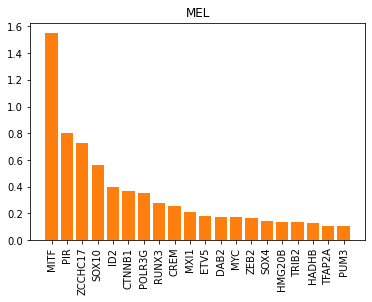

In [36]:
import seaborn as sns
df_preds_MEL['tf'] = df_preds_MEL.index
top_tfs = df_preds_MEL.preds.abs().sort_values(ascending=False).index[:20]
plt.bar(df_preds_MEL.loc[top_tfs,'tf'], df_preds_MEL.loc[top_tfs,'preds'], color='#FF7F0E')
plt.title('MEL')
# plt.bar(df_pred.loc[top_tfs,'tf'], df_pred.loc[top_tfs,'preds'], color='#1F77B4')
# plt.title('INT')
# plt.bar(df_pred.loc[top_tfs,'tf'], df_pred.loc[top_tfs,'preds'], color='#2CA02C')
# plt.title('MES')
plt.xticks(rotation=90);

In [41]:
# Compute attribution scores with motif and functional head
attr = ixg.attribute(samples_1hot, target=int(TF_idx))
attr = attr.cpu().detach().numpy()

In [41]:
# #### PROBABLY NOT NEEDED ####
# seq_len = 640
# attr_mtf = attr_mtf[seq_len//2-250:seq_len//2+250, :]
# attr_ctx = attr_ctx[seq_len//2-250:seq_len//2+250, :]
# samples_500bp = samples_1hot[seq_len//2-250:seq_len//2+250, :]

In [39]:
# Trim sequence to 500bp
# attr = attr[opt.seq_len//2-250:opt.seq_len//2+250, :]
# samples_500bp = samples_1hot[opt.seq_len//2-250:opt.seq_len//2+250, :]

640it [00:46, 13.83it/s]


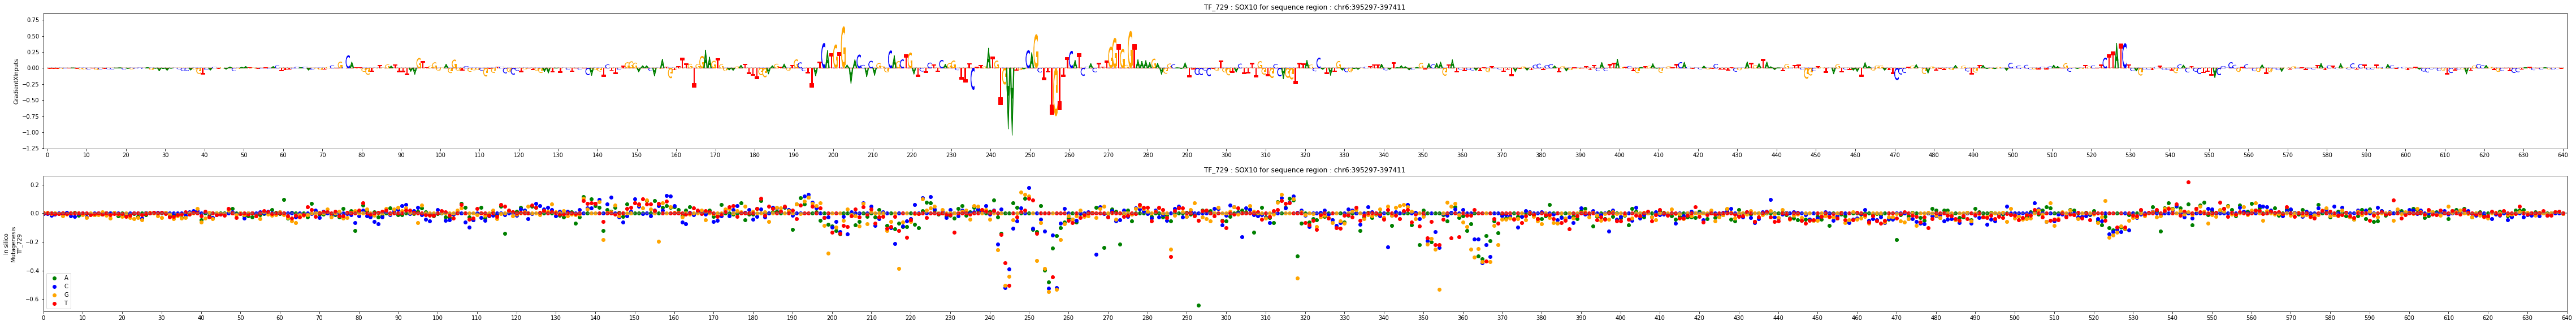

In [42]:
ntrack = 3
fig = plt.figure(figsize=(80,ntrack*5))
axes = [None, None]

_, axes[0] = utils.plot_weights((attr)*samples_1hot.cpu().detach().numpy(),
                      fig, ntrack, 1, 2,
                      title="TF_" + str(TF_idx) + ' : ' + TF + ' for sequence region : ' + reg,
                      subticks_frequency=10, ylab="GradientXInputs")

# Plot in silico mutagenesis for the selected topic
axes[1] = utils.plot_mutagenesis_givenax(model=model, fig=fig, ntrack=ntrack, track_no=3, 
                                seq_onehot=samples_1hot.to('cpu'), num_classes=TFs_idx.shape[0], 
                                TF = TF_idx, TF_name=TF, region_id=reg, seq_len=opt.seq_len, mutated_seq_len=opt.seq_len)
